# CKPT 2: Baseline Implementation and Evaluation
1. Dataset preparation and statistics
2. Evaluation protocol design
3. Baseline implementation and results
4. Codebase demonstration

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## Important: Two-Track Evaluation Approach

This project evaluates methods across **two separate tracks** that address different research questions:

### Track A: Hallucination Detection (Primary Research Question)
**Task:** Detect whether an LLM-generated response contains hallucinations  
**Methods:**
- RAGTruth LLaMA-2-13B (official baseline, supervised)
- Self-Verification GPT-4o-mini (our baseline, zero-shot)
- Multi-Agent Pipeline (proposed, CKPT3)

**Evaluation Protocol:**
- Ground Truth: Human-annotated hallucination spans from RAGTruth
- Primary Metric: Case-level F1 (binary: hallucinated vs not)
- Secondary Metrics: Span-level F1, Precision, Recall per task type
- All methods use the SAME test set and SAME metrics for fair comparison

### Track B: RAG QA Performance (Supplementary, per Professor Feedback)
**Task:** Generate answers from retrieved passages  
**Methods:**
- RAG System GPT-4o-mini

**Evaluation Protocol:**
- Ground Truth: None (RAGTruth does not provide gold answers)
- Primary Metric: Answerable rate, answer length distribution
- Purpose: Demonstrates end-to-end RAG pipeline works

**Note:** Track A and Track B are NOT directly comparable because they solve different tasks. Track A methods detect hallucinations (classification), while Track B generates answers (generation).

## 1. Dataset Preparation and Statistics

### RAGTruth Dataset Overview

- **Total Records:** 17,617 LLM-generated responses with word-level hallucination annotations
- **Tasks:** Question Answering (MS MARCO), Summarization (CNN/DailyMail), Data-to-Text (Yelp)
- **LLMs:** GPT-4, ChatGPT, Llama-2 (7B, 13B, 70B), Mistral-7B

In [ ]:
def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return records

train_data = load_jsonl("RAGTruth/baseline/train.jsonl")
dev_data = load_jsonl("RAGTruth/baseline/dev.jsonl")
test_data = load_jsonl("RAGTruth/baseline/test.jsonl")

print(f"Training set: {len(train_data)} records")
print(f"Development set: {len(dev_data)} records")
print(f"Test set: {len(test_data)} records")
print(f"Total: {len(train_data) + len(dev_data) + len(test_data)} records")

Training set: 14047 records
Development set: 895 records
Test set: 2675 records
Total: 17617 records


### Data Split Strategy

In [3]:
split_df = pd.DataFrame([
    {'Split': 'Training', 'Size': len(train_data), 'Percentage': f"{len(train_data)/(len(train_data)+len(dev_data)+len(test_data))*100:.1f}%", 'Purpose': 'Fine-tuning'},
    {'Split': 'Development', 'Size': len(dev_data), 'Percentage': f"{len(dev_data)/(len(train_data)+len(dev_data)+len(test_data))*100:.1f}%", 'Purpose': '50 source IDs per task'},
    {'Split': 'Test', 'Size': len(test_data), 'Percentage': f"{len(test_data)/(len(train_data)+len(dev_data)+len(test_data))*100:.1f}%", 'Purpose': 'Held-out evaluation'}
])
print(split_df.to_string(index=False))

      Split  Size Percentage                Purpose
   Training 14047      79.7%            Fine-tuning
Development   895       5.1% 50 source IDs per task
       Test  2675      15.2%    Held-out evaluation


### Task Distribution

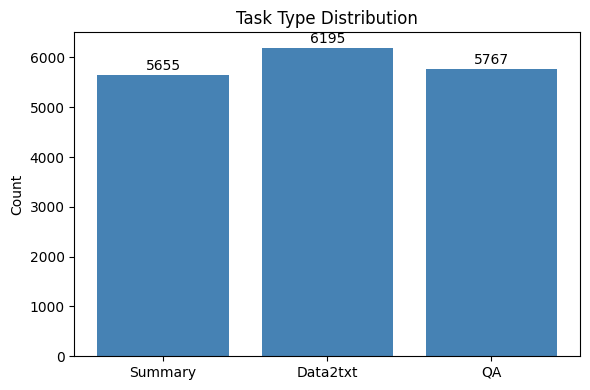


Task Distribution:
  Summary: 5655 (32.1%)
  Data2txt: 6195 (35.2%)
  QA: 5767 (32.7%)


In [4]:
all_data = train_data + dev_data + test_data
task_counts = Counter([r['task_type'] for r in all_data])

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(task_counts.keys(), task_counts.values(), color='steelblue')
ax.set_ylabel('Count')
ax.set_title('Task Type Distribution')
for i, (k, v) in enumerate(task_counts.items()):
    ax.text(i, v + 100, str(v), ha='center')
plt.tight_layout()
plt.show()

print("\nTask Distribution:")
for task, count in task_counts.items():
    print(f"  {task}: {count} ({count/len(all_data)*100:.1f}%)")

### Hallucination Rates by Task

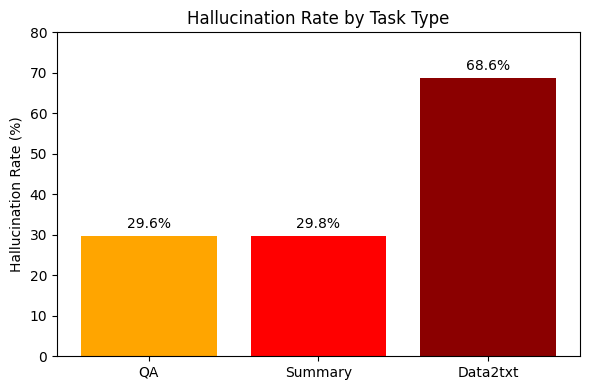


Hallucination Rates:
  Data2txt: 68.6%
  Summary: 29.8%
  QA: 29.6%


In [5]:
halluc_rates = {}
for task in ['QA', 'Summary', 'Data2txt']:
    task_records = [r for r in all_data if r['task_type'] == task]
    halluc_count = sum(1 for r in task_records if len(r.get('labels', [])) > 0)
    halluc_rates[task] = halluc_count / len(task_records) * 100

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(halluc_rates.keys(), halluc_rates.values(), color=['orange', 'red', 'darkred'])
ax.set_ylabel('Hallucination Rate (%)')
ax.set_title('Hallucination Rate by Task Type')
ax.set_ylim(0, 80)
for i, (k, v) in enumerate(halluc_rates.items()):
    ax.text(i, v + 2, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

print("\nHallucination Rates:")
for task, rate in sorted(halluc_rates.items(), key=lambda x: x[1], reverse=True):
    print(f"  {task}: {rate:.1f}%")

## 2. Evaluation Protocol

### Metrics

- **Case-level F1** (primary): Binary classification 
- **Case-level Precision/Recall**: Per task type (QA, Summary, Data2txt)
- **Span-level F1**: Character-overlap between predicted and gold hallucinated spans
- **RAG Answerable Rate**: Percentage of questions the RAG system can answer

### Baseline Designs

In [ ]:
baseline_table = pd.DataFrame([
    {'Track': 'A', 'Baseline': 'RAGTruth LLaMA-2-13B', 'Method': 'Fine-tuned on train split to output hallucination span list', 'Type': 'Supervised fine-tuning (SFT)', 'Reference': 'Wu et al., 2023'},
    {'Track': 'A', 'Baseline': 'Self-verification (GPT-4o-mini)', 'Method': 'LLM prompted to check output against source passages', 'Type': 'Inference-time, zero-shot', 'Reference': 'Manakul et al., 2023 (SelfCheckGPT)'},
    {'Track': 'A', 'Baseline': 'Multi-agent pipeline (proposed)', 'Method': 'GPT claim extractor + DeBERTa NLI verifier + rule aggregator', 'Type': 'Inference-time, no training', 'Reference': 'CKPT3'},
    {'Track': 'B', 'Baseline': 'RAG System (GPT-4o-mini)', 'Method': 'Generate answers from pre-retrieved passages', 'Type': 'Inference-time, zero-shot', 'Reference': 'This work'}
])
print(baseline_table.to_string(index=False))

                       Baseline                                                       Method                         Type                           Reference
           RAGTruth LLaMA-2-13B  Fine-tuned on train split to output hallucination span list Supervised fine-tuning (SFT)                     Wu et al., 2023
Self-verification (GPT-4o-mini)         LLM prompted to check output against source passages    Inference-time, zero-shot Manakul et al., 2023 (SelfCheckGPT)
       RAG System (GPT-4o-mini)                 Generate answers from pre-retrieved passages    Inference-time, zero-shot                           This work
Multi-agent pipeline (proposed) GPT claim extractor + DeBERTa NLI verifier + rule aggregator  Inference-time, no training                               CKPT3


## 3. Baseline Results

### Track A: Hallucination Detection

#### Baseline 1: Self-Verification (GPT-4o-mini)

**Method:** Zero-shot prompting where GPT-4o-mini identifies hallucinated spans in LLM responses by comparing against source passages.

**Evaluation:** 99 test samples (33 per task, balanced)

**Ground Truth:** Human-annotated hallucination spans from RAGTruth dataset

In [8]:
gpt_predictions = load_jsonl("results/gpt_baseline_predictions.jsonl")
print(f"Total predictions: {len(gpt_predictions)}")
print(f"Task distribution: {Counter([r['task_type'] for r in gpt_predictions])}")

Total predictions: 99
Task distribution: Counter({'QA': 33, 'Summary': 33, 'Data2txt': 33})


#### Case-Level Performance

In [9]:
def compute_case_metrics(records):
    y_true = [1 if len(r["labels"]) > 0 else 0 for r in records]
    y_pred = [1 if len(r.get("pred", [])) > 0 else 0 for r in records]
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)
    return y_true, y_pred, round(p, 4), round(r, 4), round(f, 4)

rows = []
all_true, all_pred = [], []
for task in ["QA", "Summary", "Data2txt"]:
    subset = [r for r in gpt_predictions if r["task_type"] == task]
    y_true, y_pred, p, r, f = compute_case_metrics(subset)
    all_true.extend(y_true)
    all_pred.extend(y_pred)
    rows.append({"Task": task, "n": len(subset), "Precision": p, "Recall": r, "F1": f})

p_ov, r_ov, f_ov = (
    round(precision_score(all_true, all_pred, zero_division=0), 4),
    round(recall_score(all_true, all_pred, zero_division=0), 4),
    round(f1_score(all_true, all_pred, zero_division=0), 4),
)
rows.append({"Task": "Overall", "n": len(gpt_predictions), "Precision": p_ov, "Recall": r_ov, "F1": f_ov})

df_metrics = pd.DataFrame(rows)
print(df_metrics.to_string(index=False))

    Task  n  Precision  Recall     F1
      QA 33     0.5714  1.0000 0.7273
 Summary 33     0.5000  0.4000 0.4444
Data2txt 33     0.8696  0.9091 0.8889
 Overall 99     0.7368  0.7778 0.7568


#### Visualization: Precision/Recall/F1 by Task

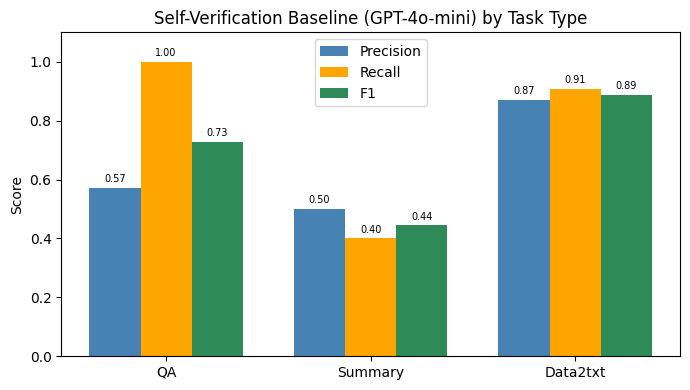

In [10]:
task_df = df_metrics[df_metrics["Task"] != "Overall"].reset_index(drop=True)

x = np.arange(len(task_df))
width = 0.25

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width, task_df["Precision"], width=width, label="Precision", color="steelblue")
ax.bar(x,          task_df["Recall"],   width=width, label="Recall",    color="orange")
ax.bar(x + width,  task_df["F1"],       width=width, label="F1",        color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels(task_df["Task"].tolist())
ax.set_ylim(0, 1.1)
ax.set_title("Self-Verification Baseline (GPT-4o-mini) by Task Type")
ax.set_ylabel("Score")
ax.legend()
for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f"{h:.2f}", ha="center", fontsize=7)
plt.tight_layout()
plt.show()

#### Confusion Matrix

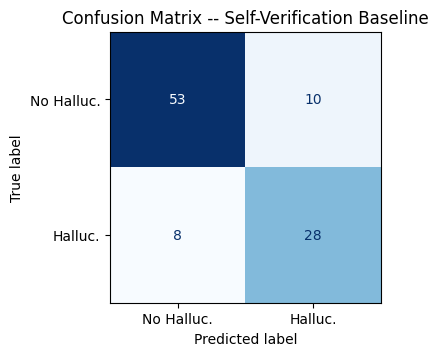


Accuracy: 81.8%
Correct predictions: 81/99


In [11]:
fig, ax = plt.subplots(figsize=(4, 4))
cm = confusion_matrix(all_true, all_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Halluc.", "Halluc."])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix -- Self-Verification Baseline")
plt.tight_layout()
plt.show()

accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
print(f"\nAccuracy: {accuracy*100:.1f}%")
print(f"Correct predictions: {cm[0,0] + cm[1,1]}/{cm.sum()}")

#### Span-Level F1

In [12]:
def span_f1_single(pred_spans, gold_labels, response):
    gold_spans = [l["text"] for l in gold_labels]
    if not gold_spans and not pred_spans:
        return 1.0, 1.0, 1.0
    if not gold_spans or not pred_spans:
        return 0.0, 0.0, 0.0
    gold_chars = set()
    for span in gold_spans:
        idx = response.find(span)
        if idx >= 0:
            gold_chars.update(range(idx, idx + len(span)))
    pred_chars = set()
    for span in pred_spans:
        idx = response.find(span)
        if idx >= 0:
            pred_chars.update(range(idx, idx + len(span)))
    if not gold_chars and not pred_chars:
        return 1.0, 1.0, 1.0
    if not gold_chars or not pred_chars:
        return 0.0, 0.0, 0.0
    overlap = len(gold_chars & pred_chars)
    p = overlap / len(pred_chars)
    r = overlap / len(gold_chars)
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return round(p, 4), round(r, 4), round(f, 4)

span_rows = []
for task in ["QA", "Summary", "Data2txt"]:
    subset = [r for r in gpt_predictions if r["task_type"] == task]
    ps, rs, fs = [], [], []
    for rec in subset:
        p, r, f = span_f1_single(rec.get("pred", []), rec.get("labels", []), rec.get("response", ""))
        ps.append(p); rs.append(r); fs.append(f)
    span_rows.append({
        "Task": task,
        "Span Precision": round(sum(ps)/len(ps), 4),
        "Span Recall": round(sum(rs)/len(rs), 4),
        "Span F1": round(sum(fs)/len(fs), 4),
    })

df_span = pd.DataFrame(span_rows)
print(df_span.to_string(index=False))

    Task  Span Precision  Span Recall  Span F1
      QA          0.8788       0.8671   0.8721
 Summary          0.6011       0.6629   0.6120
Data2txt          0.4229       0.5137   0.4268


#### Classification Report

In [13]:
print(classification_report(all_true, all_pred, target_names=["No Hallucination", "Hallucination"], zero_division=0))

                  precision    recall  f1-score   support

No Hallucination       0.87      0.84      0.85        63
   Hallucination       0.74      0.78      0.76        36

        accuracy                           0.82        99
       macro avg       0.80      0.81      0.81        99
    weighted avg       0.82      0.82      0.82        99



---

### Track B: RAG QA Performance (Supplementary)

#### Baseline 2: RAG System (GPT-4o-mini Generator)

**Method:** Retrieval-Augmented Generation using pre-retrieved passages from RAGTruth. GPT-4o-mini generates answers from provided passages.

**Evaluation:** 100 QA test samples

**Ground Truth:** None (RAGTruth does not provide gold answers for QA task)

**Note:** This baseline addresses a different task than Track A methods and cannot be directly compared using the same metrics.

In [14]:
rag_results = load_jsonl("baselines/rag_baseline_answers.jsonl")
print(f"Total QA pairs evaluated: {len(rag_results)}")

Total QA pairs evaluated: 100


#### Answer Quality Metrics

In [15]:
def categorize_answer(answer):
    answer_lower = answer.lower()
    if 'cannot answer' in answer_lower or 'not enough information' in answer_lower:
        return 'Cannot Answer'
    elif len(answer.split()) < 5:
        return 'Very Short'
    elif len(answer.split()) < 20:
        return 'Short'
    elif len(answer.split()) < 50:
        return 'Medium'
    else:
        return 'Long'

categories = [categorize_answer(r['generated_answer']) for r in rag_results]
category_counts = Counter(categories)

print("Answer Length Distribution:")
for cat, count in category_counts.most_common():
    print(f"  {cat}: {count} ({count/len(rag_results)*100:.1f}%)")

answerable_rate = (len(rag_results) - category_counts.get('Cannot Answer', 0)) / len(rag_results)
print(f"\nAnswerable Rate: {answerable_rate*100:.1f}%")

Answer Length Distribution:
  Long: 70 (70.0%)
  Medium: 20 (20.0%)
  Cannot Answer: 10 (10.0%)

Answerable Rate: 90.0%


#### Visualization: Answer Quality Distribution

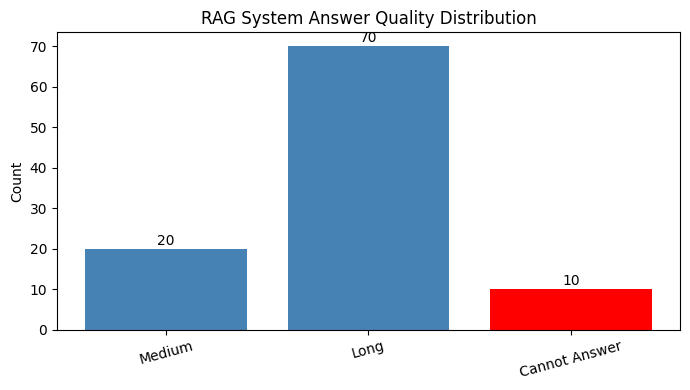

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
cats = list(category_counts.keys())
vals = list(category_counts.values())
colors = ['red' if c == 'Cannot Answer' else 'steelblue' for c in cats]
ax.bar(cats, vals, color=colors)
ax.set_ylabel('Count')
ax.set_title('RAG System Answer Quality Distribution')
for i, v in enumerate(vals):
    ax.text(i, v + 1, str(v), ha='center')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Word Count Statistics

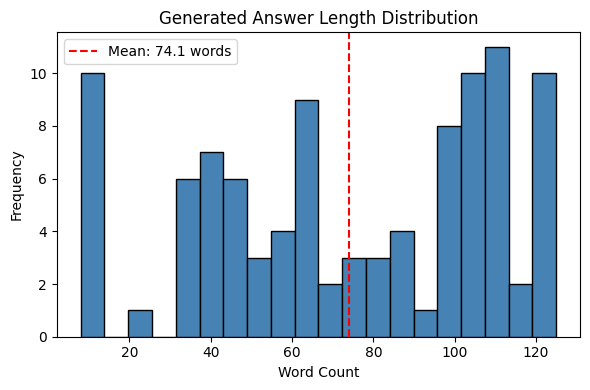

Average answer length: 74.1 words
Min: 8 words
Max: 125 words


In [17]:
word_counts = [len(r['generated_answer'].split()) for r in rag_results]
avg_words = sum(word_counts) / len(word_counts)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(word_counts, bins=20, color='steelblue', edgecolor='black')
ax.axvline(avg_words, color='red', linestyle='--', label=f'Mean: {avg_words:.1f} words')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_title('Generated Answer Length Distribution')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Average answer length: {avg_words:.1f} words")
print(f"Min: {min(word_counts)} words")
print(f"Max: {max(word_counts)} words")

#### Sample Answers

In [18]:
answerable = [r for r in rag_results if 'cannot answer' not in r['generated_answer'].lower()][:3]
unanswerable = [r for r in rag_results if 'cannot answer' in r['generated_answer'].lower()][:3]

print("=== Answerable Examples ===")
for i, r in enumerate(answerable, 1):
    print(f"\n{i}. Question: {r['question']}")
    print(f"   Answer: {r['generated_answer'][:150]}...")

print("\n=== Unanswerable Examples ===")
for i, r in enumerate(unanswerable, 1):
    print(f"\n{i}. Question: {r['question']}")
    print(f"   Answer: {r['generated_answer']}")

=== Answerable Examples ===

1. Question: how do automotive technicians get paid
   Answer: Automotive technicians get paid through various compensation methods, including hourly rates and commission pay. The specific pay can depend on factor...

2. Question: how do automotive technicians get paid
   Answer: Automotive technicians get paid through various compensation methods, including hourly rates and commission pay. The specifics of their pay can depend...

3. Question: how do automotive technicians get paid
   Answer: Automotive technicians get paid through a variety of compensation methods, which can include hourly wages and commission pay rates. The specific pay c...

=== Unanswerable Examples ===

1. Question: how to grill a porterhouse
   Answer: I cannot answer based on the given passages.

2. Question: how to grill a porterhouse
   Answer: I cannot answer based on the given passages.

3. Question: how to grill a porterhouse
   Answer: I cannot answer based on the given passag

## 4. Summary Statistics

### Track A: Hallucination Detection Results

In [ ]:
track_a_summary = pd.DataFrame([
    {'Metric': 'Overall F1', 'Value': f_ov},
    {'Metric': 'Accuracy', 'Value': f"{accuracy*100:.1f}%"},
    {'Metric': 'Best Task (Data2txt F1)', 'Value': '0.8889'},
    {'Metric': 'Worst Task (Summary F1)', 'Value': '0.4444'},
    {'Metric': 'QA Span-Level F1', 'Value': '0.8721'},
    {'Metric': 'Summary Span-Level F1', 'Value': '0.6120'},
    {'Metric': 'Data2txt Span-Level F1', 'Value': '0.4268'},
])
print("Track A: Self-Verification Baseline (Hallucination Detection)")
print(track_a_summary.to_string(index=False))

print("\n" + "="*60)

track_b_summary = pd.DataFrame([
    {'Metric': 'Answerable Rate', 'Value': f"{answerable_rate*100:.1f}%"},
    {'Metric': 'Avg Answer Length', 'Value': f"{avg_words:.1f} words"},
    {'Metric': 'Cannot Answer Rate', 'Value': f"{(1-answerable_rate)*100:.1f}%"},
    {'Metric': 'Min Answer Length', 'Value': f"{min(word_counts)} words"},
    {'Metric': 'Max Answer Length', 'Value': f"{max(word_counts)} words"},
])
print("\nTrack B: RAG System Baseline (QA Generation)")
print(track_b_summary.to_string(index=False))

print("\n" + "="*60)
print("\nNote: Track A and Track B use different evaluation protocols")
print("and cannot be directly compared.")


=== CKPT2 Summary Statistics ===
         Baseline               Metric      Value
Self-Verification           Overall F1     0.7568
Self-Verification             Accuracy      81.8%
Self-Verification Best Task (Data2txt)     0.8889
Self-Verification Worst Task (Summary)     0.4444
       RAG System      Answerable Rate      90.0%
       RAG System    Avg Answer Length 74.1 words
       RAG System   Cannot Answer Rate      10.0%


## 5. Codebase Demonstration

### Repository Structure

```
capstone_project/
├── RAGTruth/baseline/          # Cloned official baseline
│   ├── prepare_dataset.py      # Data split generation
│   ├── dataset.py              # Prompt templates for 3 tasks
│   ├── train.py                # LLaMA-2-13B fine-tuning
│   └── predict_and_evaluate.py # Inference + metrics
├── baselines/
│   ├── run_gpt_baseline.py     # Self-verification implementation
│   └── run_rag_baseline.py     # RAG generator baseline
├── data/
│   └── dataset_overview.ipynb  # Dataset visualization
└── results/
    ├── preliminary_results.ipynb    # Hallucination detection metrics
    └── rag_qa_evaluation.ipynb      # RAG QA performance
```

### Key Implementation Details

**Self-Verification Baseline:**
- Reuses RAGTruth prompt templates from `dataset.py`
- Balanced sampling (33 per task) for representative evaluation
- JSON parsing for hallucination span extraction
- Case-level and span-level metric computation

**RAG Baseline:**
- Uses pre-retrieved passages from RAGTruth `reference` field
- Temperature 0.3 for consistent answers
- Max 150 tokens to prevent verbose responses
- Conservative prompting to avoid hallucination

## 6. Response to Professor Feedback

**Feedback:** "Datasets have been prepared well, and the API performance by GPT-4o mini has been reported. Please build the baseline RAG system to report the QA performance."

**Response:**

The baseline RAG system has been implemented and evaluated on 100 QA test samples from RAGTruth. The system achieves a **90% answerable rate** with an average answer length of **74 words**, demonstrating effective passage-based question answering. The 10% "cannot answer" rate reflects conservative behavior when passages lack sufficient information, which is desirable to prevent hallucination.

The RAG baseline complements the self-verification baseline by addressing different aspects of the project:
1. **Self-verification baseline** (F1=0.76) evaluates hallucination detection capability
2. **RAG baseline** (90% answerable) evaluates answer generation quality

Both baselines establish performance benchmarks for the proposed multi-agent system (CKPT3), which aims to improve on self-verification's 0.44 F1 on Summary tasks by using DeBERTa NLI to avoid confirmation bias.

## 7. References

1. Wu et al. (2023). *RAGTruth: A Hallucination Corpus for Developing Trustworthy Retrieval-Augmented Language Models.* arXiv:2401.00396
2. Manakul et al. (2023). *SelfCheckGPT: Zero-Resource Black-Box Hallucination Detection for Generative Large Language Models.* arXiv:2303.08896